
# Judea Pearl's ladder of causation through a predictive-maintenance SCM

This notebook is a lab-style introduction to **Judea Pearl's approach to causality** using a small, fully reproducible synthetic predictive-maintenance example.

The notebook follows four steps:

1. build a **synthetic dataset** over seven variables from a known structural causal model (SCM);
2. work at **level 1 of the ladder** (association): conditional independence, d-separation, and the PC algorithm;
3. work at **level 2 of the ladder** (intervention): identify and estimate a causal effect with the **backdoor criterion**;
4. work at **level 3 of the ladder** (counterfactuals): infer individual exogenous shocks and answer machine-specific *what if* questions.

The context is a rotating industrial machine. The seven observed variables are:

- **Temp**: ambient temperature around the machine room
- **Load**: operating load of the machine
- **Lubrication**: lubrication quality index
- **Vibration**: vibration amplitude
- **Wear**: bearing wear index
- **Current**: motor current draw
- **Failure**: failure-risk score

The data-generating SCM is written out directly because students should be able to inspect every equation. The causal analysis uses standard libraries:

- `causal-learn` for Fisher-Z conditional independence tests and PC discovery;
- `networkx` for d-separation checks;
- `DoWhy` / `dowhy.gcm` for adjustment identification, intervention samples, and counterfactual samples.


In [1]:

# Colab/local setup: install the required causal libraries at known-working versions.
# In Google Colab this cell prepares the environment. Locally it is a no-op when versions already match.
import importlib.metadata as importlib_metadata
import subprocess
import sys

REQUIRED_PACKAGES = {
    "causal-learn": "0.1.4.5",
    "dowhy": "0.14",
}

to_install = []
for package_name, required_version in REQUIRED_PACKAGES.items():
    try:
        installed_version = importlib_metadata.version(package_name)
    except importlib_metadata.PackageNotFoundError:
        installed_version = None
    if installed_version != required_version:
        to_install.append(f"{package_name}=={required_version}")

if to_install:
    print("Installing:", to_install)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *to_install])
else:
    print("Required causal libraries are already installed at the pinned versions.")


Installing: ['causal-learn==0.1.4.5', 'dowhy==0.14']


In [2]:

import contextlib
import io
import itertools
import math
import os
import warnings
from dataclasses import dataclass

# Helpful on locked-down local systems; harmless in Colab.
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("XDG_CACHE_HOME", "/tmp")

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from causallearn.search.ConstraintBased.PC import pc as causallearn_pc
from causallearn.utils.cit import CIT
from dowhy import CausalModel
import dowhy.gcm as gcm
from dowhy.gcm import ml as gcm_ml
from IPython.display import display
from networkx.algorithms.d_separation import find_minimal_d_separator, is_d_separator
from scipy import stats
from sklearn.linear_model import LinearRegression

warnings.filterwarnings("ignore", message="IProgress not found.*")
warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 20260429
rng = np.random.default_rng(SEED)
np.random.seed(SEED)
pd.set_option("display.max_columns", 50)
pd.set_option("display.precision", 3)

print("Imports complete.")


/home/dt2025ghidini/Documents/digital_transformations/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports complete.



## 1. A structural causal model for predictive maintenance

We use a **linear-Gaussian SCM**. Each observed variable is computed from its parents plus an exogenous noise term. The exogenous terms are independent shocks: room conditions, operating variation, measurement noise, unmeasured local mechanical details, and so on.

The causal story is:

- hotter environments degrade lubrication;
- higher load and poorer lubrication increase vibration;
- vibration and poor lubrication increase wear;
- higher load increases current;
- wear and current increase failure risk.

The **true SCM used to generate the data is directed**. Every arrow below is a structural assignment direction, not an association.

$$
\text{Temp} \to \text{Lubrication},\quad
\text{Load} \to \text{Vibration},\quad
\text{Load} \to \text{Current},\quad
\text{Lubrication} \to \text{Vibration},\quad
\text{Lubrication} \to \text{Wear},\quad
\text{Vibration} \to \text{Wear},\quad
\text{Wear} \to \text{Failure},\quad
\text{Current} \to \text{Failure}.
$$

The structural equations used to generate the data are deliberately explicit:

$$
\begin{aligned}
\text{Temp} &= 28 + U_{\text{Temp}} \\
\text{Load} &= 70 + U_{\text{Load}} \\
\text{Lubrication} &= 80 - 1.0(\text{Temp}-28) + U_{\text{Lubrication}} \\
\text{Vibration} &= 6 + 0.10(\text{Load}-70) - 0.12(\text{Lubrication}-80) + U_{\text{Vibration}} \\
\text{Wear} &= 50 + 2.2(\text{Vibration}-6) - 0.45(\text{Lubrication}-80) + U_{\text{Wear}} \\
\text{Current} &= 30 + 0.30(\text{Load}-70) + U_{\text{Current}} \\
\text{Failure} &= 40 + 1.0(\text{Wear}-50) + 0.8(\text{Current}-30) + U_{\text{Failure}}.
\end{aligned}
$$


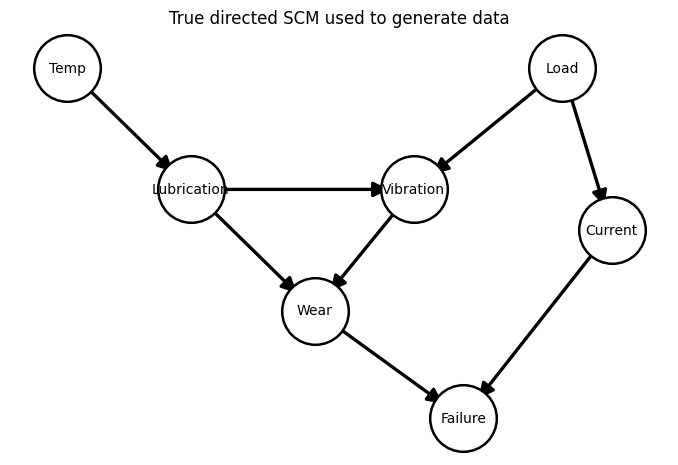

In [12]:

@dataclass
class PredictiveMaintenanceSCM:
    seed: int = SEED

    def __post_init__(self):
        self.graph = nx.DiGraph([
            ("Temp", "Lubrication"),
            ("Load", "Vibration"),
            ("Load", "Current"),
            ("Lubrication", "Vibration"),
            ("Lubrication", "Wear"),
            ("Vibration", "Wear"),
            ("Wear", "Failure"),
            ("Current", "Failure"),
        ])
        self.order = list(nx.topological_sort(self.graph))
        self.positions = {
            "Temp": (-2.0, 1.3),
            "Load": (2.0, 1.3),
            "Lubrication": (-1.0, 0.4),
            "Vibration": (0.8, 0.4),
            "Current": (2.4, 0.1),
            "Wear": (0.0, -0.5),
            "Failure": (1.2, -1.3),
        }
        self.exogenous_scales = {
            "U_Temp": 4.0,
            "U_Load": 10.0,
            "U_Lubrication": 5.0,
            "U_Vibration": 1.2,
            "U_Wear": 3.0,
            "U_Current": 2.0,
            "U_Failure": 4.0,
        }

    def sample_exogenous(self, n, seed=None):
        local_rng = np.random.default_rng(self.seed if seed is None else seed)
        return pd.DataFrame({
            name: local_rng.normal(0, scale, size=n)
            for name, scale in self.exogenous_scales.items()
        })

    def evaluate(self, exogenous, interventions=None):
        """Evaluate structural equations, optionally replacing equations by do-interventions."""
        interventions = interventions or {}
        exogenous = pd.DataFrame(exogenous).copy()
        n = len(exogenous)
        values = {}

        for node in self.order:
            if node in interventions:
                fixed = interventions[node]
                if np.isscalar(fixed):
                    values[node] = np.full(n, fixed, dtype=float)
                else:
                    arr = np.asarray(fixed, dtype=float)
                    if arr.shape[0] != n:
                        raise ValueError(f"Intervention on {node} has incompatible length")
                    values[node] = arr
                continue

            if node == "Temp":
                values[node] = 28 + exogenous["U_Temp"].to_numpy()
            elif node == "Load":
                values[node] = 70 + exogenous["U_Load"].to_numpy()
            elif node == "Lubrication":
                values[node] = 80 - 1.0 * (values["Temp"] - 28) + exogenous["U_Lubrication"].to_numpy()
            elif node == "Vibration":
                values[node] = (
                    6
                    + 0.10 * (values["Load"] - 70)
                    - 0.12 * (values["Lubrication"] - 80)
                    + exogenous["U_Vibration"].to_numpy()
                )
            elif node == "Wear":
                values[node] = (
                    50
                    + 2.2 * (values["Vibration"] - 6)
                    - 0.45 * (values["Lubrication"] - 80)
                    + exogenous["U_Wear"].to_numpy()
                )
            elif node == "Current":
                values[node] = 30 + 0.30 * (values["Load"] - 70) + exogenous["U_Current"].to_numpy()
            elif node == "Failure":
                values[node] = (
                    40
                    + 1.0 * (values["Wear"] - 50)
                    + 0.8 * (values["Current"] - 30)
                    + exogenous["U_Failure"].to_numpy()
                )
            else:
                raise KeyError(node)

        return pd.DataFrame(values)

    def sample(self, n=3000, seed=None):
        U = self.sample_exogenous(n=n, seed=seed)
        X = self.evaluate(U)
        return X, U

    def abduce(self, observation):
        """Invert the structural equations to recover one unit's exogenous shocks."""
        obs = pd.Series(observation)
        u = {
            "U_Temp": obs["Temp"] - 28,
            "U_Load": obs["Load"] - 70,
        }
        u["U_Lubrication"] = obs["Lubrication"] - (80 - 1.0 * (obs["Temp"] - 28))
        u["U_Vibration"] = obs["Vibration"] - (
            6 + 0.10 * (obs["Load"] - 70) - 0.12 * (obs["Lubrication"] - 80)
        )
        u["U_Wear"] = obs["Wear"] - (
            50 + 2.2 * (obs["Vibration"] - 6) - 0.45 * (obs["Lubrication"] - 80)
        )
        u["U_Current"] = obs["Current"] - (30 + 0.30 * (obs["Load"] - 70))
        u["U_Failure"] = obs["Failure"] - (
            40 + 1.0 * (obs["Wear"] - 50) + 0.8 * (obs["Current"] - 30)
        )
        return pd.DataFrame([u])

    def counterfactual(self, observation, interventions):
        U_i = self.abduce(observation)
        return self.evaluate(U_i, interventions=interventions).iloc[0]


def draw_graph(directed_edges, undirected_edges=None, title="Graph", undirected_label=None):
    undirected_edges = undirected_edges or []
    fig, ax = plt.subplots(figsize=(8.5, 5.5))
    ax.set_title(title)

    nodes = list(scm.graph.nodes)
    nx.draw_networkx_nodes(
        scm.graph,
        scm.positions,
        nodelist=nodes,
        node_size=2300,
        node_color="white",
        edgecolors="black",
        linewidths=1.8,
        ax=ax,
    )
    nx.draw_networkx_labels(scm.graph, scm.positions, font_size=10, ax=ax)

    nx.draw_networkx_edges(
        scm.graph,
        scm.positions,
        edgelist=list(directed_edges),
        arrows=True,
        arrowstyle="-|>",
        arrowsize=22,
        min_source_margin=18,
        min_target_margin=18,
        width=2.4,
        edge_color="black",
        ax=ax,
    )

    if undirected_edges:
        undirected_graph = nx.Graph()
        undirected_graph.add_nodes_from(nodes)
        undirected_graph.add_edges_from(undirected_edges)
        nx.draw_networkx_edges(
            undirected_graph,
            scm.positions,
            edgelist=list(undirected_edges),
            arrows=False,
            style="dashed",
            width=2.6,
            edge_color="gray",
            ax=ax,
        )
        if undirected_label:
            labels = {edge: undirected_label for edge in undirected_edges}
            nx.draw_networkx_edge_labels(
                undirected_graph,
                scm.positions,
                edge_labels=labels,
                font_size=8,
                font_color="dimgray",
                rotate=False,
                ax=ax,
            )

    ax.axis("off")
    plt.show()


scm = PredictiveMaintenanceSCM()
draw_graph(scm.graph.edges(), title="True directed SCM used to generate data")


In [13]:

X, U = scm.sample(n=3000, seed=SEED)

print("Observed data shape:", X.shape)
print("Exogenous shocks shape:", U.shape)
display(X.head())
display(X.describe().T[["mean", "std", "min", "max"]])


Observed data shape: (3000, 7)
Exogenous shocks shape: (3000, 7)


,Temp,Load,Lubrication,Current,Vibration,Wear,Failure
0,25.736,83.628,82.009,33.223,5.369,46.413,34.362
1,29.612,61.035,82.501,26.583,5.531,51.417,44.961
2,24.085,63.835,79.999,26.027,3.859,42.419,26.300
3,30.287,61.759,79.534,27.035,4.776,43.728,29.981
4,22.642,84.384,79.537,35.074,7.874,55.677,53.015


,mean,std,min,max
Temp,28.004,4.029,12.447,44.734
Load,70.089,10.047,28.054,104.345
Lubrication,80.017,6.502,57.430,99.451
Current,29.994,3.631,17.008,42.100
Vibration,5.944,1.760,-1.319,12.739
Wear,49.890,6.533,23.497,74.295
Failure,39.912,8.727,7.439,71.289



The data are synthetic, so we can inspect both observed variables `X` and the normally distributed exogenous shocks `U`. In real maintenance data we would see only `X`; the hidden shocks are useful here because they let us verify the data-generating process exactly.


In [14]:

shock_summary = pd.DataFrame({
    "target_sd_used_by_SCM": scm.exogenous_scales,
    "sample_mean": U.mean(),
    "sample_sd": U.std(ddof=1),
})

display(shock_summary)

direct_effects = pd.DataFrame([
    ("Temp", "Lubrication", -1.0, "hotter room lowers lubrication quality"),
    ("Load", "Vibration", 0.10, "higher load raises vibration"),
    ("Lubrication", "Vibration", -0.12, "better lubrication lowers vibration"),
    ("Lubrication", "Wear", -0.45, "better lubrication lowers wear"),
    ("Vibration", "Wear", 2.2, "vibration strongly raises wear"),
    ("Load", "Current", 0.30, "higher load raises current"),
    ("Wear", "Failure", 1.0, "wear raises failure risk"),
    ("Current", "Failure", 0.8, "current raises failure risk"),
], columns=["parent", "child", "coefficient", "interpretation"])

display(direct_effects)


,target_sd_used_by_SCM,sample_mean,sample_sd
U_Temp,4.0,0.004,4.029
U_Load,10.0,0.089,10.047
U_Lubrication,5.0,0.021,4.999
U_Vibration,1.2,-0.063,1.178
U_Wear,3.0,0.021,2.959
U_Current,2.0,-0.033,1.991
U_Failure,4.0,0.028,3.986


,parent,child,coefficient,interpretation
0,Temp,Lubrication,-1.00,hotter room lowers lubrication quality
1,Load,Vibration,0.10,higher load raises vibration
2,Lubrication,Vibration,-0.12,better lubrication lowers vibration
3,Lubrication,Wear,-0.45,better lubrication lowers wear
4,Vibration,Wear,2.20,vibration strongly raises wear
5,Load,Current,0.30,higher load raises current
6,Wear,Failure,1.00,wear raises failure risk
7,Current,Failure,0.80,current raises failure risk



A quick correlation check already suggests the story:

- **Load** is strongly associated with **Current** and positively associated with **Vibration**;
- **Lubrication** is negatively associated with **Vibration** and **Wear**;
- **Wear** and **Current** both track **Failure**.

But correlations alone are only **associational**. To move toward causality we need the graph and the conditional independence structure.

**Short exercise:** Change the standard deviation of `U_Wear` from `3.0` to `8.0`, rerun the data-generation cells, and explain which relationships become visually noisier.


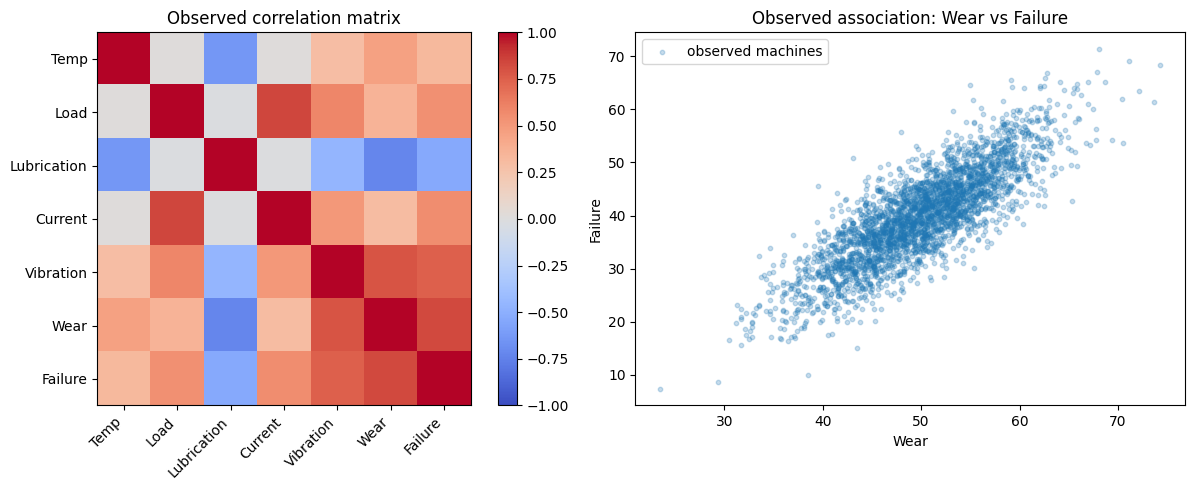

In [15]:
# U_whear = 3.0
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

im = axes[0].imshow(X.corr(), cmap="coolwarm", vmin=-1, vmax=1)
axes[0].set_xticks(range(len(X.columns)))
axes[0].set_xticklabels(X.columns, rotation=45, ha="right")
axes[0].set_yticks(range(len(X.columns)))
axes[0].set_yticklabels(X.columns)
axes[0].set_title("Observed correlation matrix")
fig.colorbar(im, ax=axes[0], fraction=0.046)

axes[1].scatter(X["Wear"], X["Failure"], s=10, alpha=0.25, label="observed machines")
axes[1].set_xlabel("Wear")
axes[1].set_ylabel("Failure")
axes[1].set_title("Observed association: Wear vs Failure")
axes[1].legend()

plt.tight_layout()
plt.show()


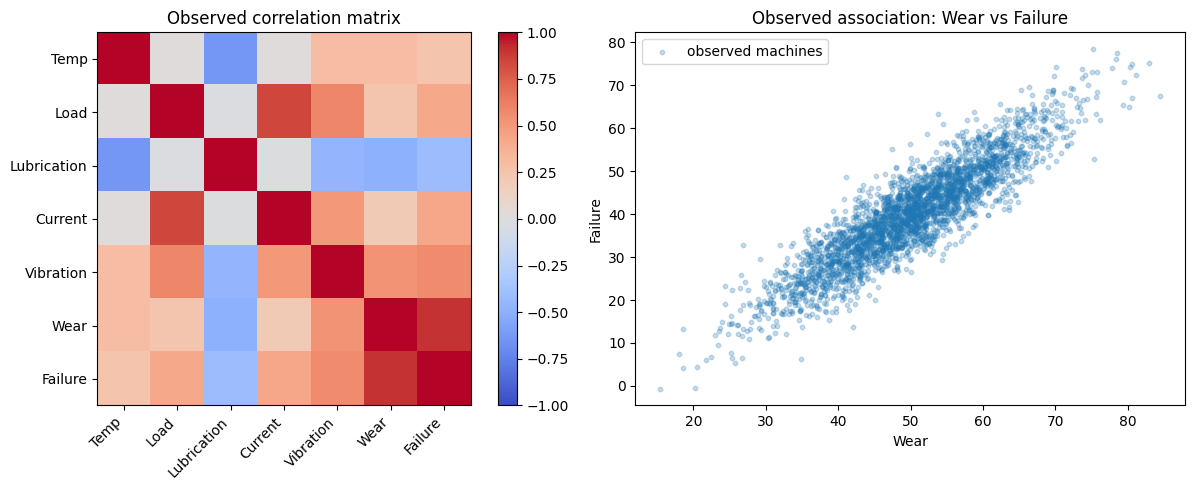

In [ ]:
#with U_whear = 8.0
# temp is less correlated, lubrificant and vibration are more correlated, 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

im = axes[0].imshow(X.corr(), cmap="coolwarm", vmin=-1, vmax=1)
axes[0].set_xticks(range(len(X.columns)))
axes[0].set_xticklabels(X.columns, rotation=45, ha="right")
axes[0].set_yticks(range(len(X.columns)))
axes[0].set_yticklabels(X.columns)
axes[0].set_title("Observed correlation matrix")
fig.colorbar(im, ax=axes[0], fraction=0.046)

axes[1].scatter(X["Wear"], X["Failure"], s=10, alpha=0.25, label="observed machines")
axes[1].set_xlabel("Wear")
axes[1].set_ylabel("Failure")
axes[1].set_title("Observed association: Wear vs Failure")
axes[1].legend()

plt.tight_layout()
plt.show()



## 2. Level 1: association, conditional independence, and the PC algorithm

At the first rung of Pearl's ladder we ask questions of the form:

- *What is associated with what?*
- *What becomes independent after conditioning on what?*

For continuous data generated by a linear-Gaussian SCM, the standard conditional independence test is a **partial-correlation / Fisher-Z** test. If two variables have zero partial correlation after conditioning on a set $Z$, then a linear-Gaussian model treats them as conditionally independent. The Fisher-Z test is introduced in https://digital.library.adelaide.edu.au/bitstream/2440/15169/1/14.pdf

We also show a **permutation test on regression residuals**. It is not the test PC uses here, but it is useful pedagogically: regress $X$ and $Y$ on the conditioning variables, then test whether the two residual series are still correlated after randomly permuting one residual series. See the documentation at https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.permutation_test.html

The Fisher Z test of conditional independence is a parametric test mainly used for continuous variables under an approximate Gaussian and linearity assumption. To test whether X⊥Y|S, it computes the partial correlation between X and Y after adjusting for the conditioning set S. If that partial correlation is close to zero, the variables are treated as conditionally independent. The correlation is transformed with the Fisher z-transform so that, under the null hypothesis, the test statistic is approximately normal. This makes the test fast and convenient, which is why it is commonly used in algorithms such as PC. Its limitation is that it may miss nonlinear or non-Gaussian dependencies.

A permutation test is a more general, nonparametric alternative. The idea is to measure some test statistic that captures dependence between X and Y given S, then repeatedly shuffle one variable in a way that breaks the dependence while preserving the rest of the structure, and recompute the statistic many times. This produces an empirical null distribution. The p-value is the proportion of shuffled datasets that produce a statistic at least as extreme as the observed one. Permutation tests are attractive because they make fewer distributional assumptions and can be adapted to more flexible dependence measures, but they are usually much slower than Fisher Z and depend on how the permutation scheme is designed for the conditional case.

In this notebook:

- Fisher-Z p-values come from `causal-learn`'s `CIT(..., method="fisherz")`;
- permutation p-values come from `scipy.stats.permutation_test` after residualization with `sklearn.linear_model.LinearRegression`.


In [16]:

def regression_residuals(data, target, conditioned_on=None):
    conditioned_on = conditioned_on or []
    y = data[target].to_numpy(float)
    if not conditioned_on:
        return y - y.mean()

    model = LinearRegression()
    model.fit(data[conditioned_on].to_numpy(float), y)
    return y - model.predict(data[conditioned_on].to_numpy(float))


def residual_correlation(data, x, y, conditioned_on=None):
    rx = regression_residuals(data, x, conditioned_on)
    ry = regression_residuals(data, y, conditioned_on)
    return float(np.corrcoef(rx, ry)[0, 1])


def fisher_z_ci_test(data, x, y, conditioned_on=None):
    conditioned_on = conditioned_on or []
    columns = list(data.columns)
    ci_tester = CIT(data[columns].to_numpy(float), method="fisherz")
    p_value = float(ci_tester(
        columns.index(x),
        columns.index(y),
        [columns.index(z) for z in conditioned_on],
    ))
    return {
        "partial_r": residual_correlation(data, x, y, conditioned_on),
        "p_value": p_value,
    }


def permutation_residual_test(data, x, y, conditioned_on=None, n_resamples=1000):
    conditioned_on = conditioned_on or []
    rx = regression_residuals(data, x, conditioned_on)
    ry = regression_residuals(data, y, conditioned_on)

    def statistic(a, b):
        return np.corrcoef(a, b)[0, 1]

    result = stats.permutation_test(
        (rx, ry),
        statistic,
        permutation_type="pairings",
        alternative="two-sided",
        n_resamples=n_resamples,
        random_state=SEED,
    )
    return {
        "residual_r": float(statistic(rx, ry)),
        "p_value": float(result.pvalue),
    }


def compare_ci_tests(data, x, y, conditioned_on=None):
    conditioned_on = conditioned_on or []
    fisher = fisher_z_ci_test(data, x, y, conditioned_on)
    permutation = permutation_residual_test(data, x, y, conditioned_on)
    return {
        "x": x,
        "y": y,
        "conditioned_on": ", ".join(conditioned_on) if conditioned_on else "<none>",
        "FisherZ_partial_r": fisher["partial_r"],
        "FisherZ_p_value": fisher["p_value"],
        "Permutation_residual_r": permutation["residual_r"],
        "Permutation_p_value": permutation["p_value"],
    }



### 2.1 D-separation in a fork and in a collider

Two standard motifs are worth checking explicitly.

**Fork:** `Load -> Vibration` and `Load -> Current`

- marginally, `Vibration` and `Current` should be associated;
- conditioning on the common cause `Load` should block the path.

**Collider:** `Load -> Vibration <- Lubrication`

- marginally, `Load` and `Lubrication` should be independent;
- conditioning on the collider `Vibration` should *open* the path and create dependence.


In [17]:

examples = pd.DataFrame([
    compare_ci_tests(X, "Vibration", "Current", conditioned_on=[]),
    compare_ci_tests(X, "Vibration", "Current", conditioned_on=["Load"]),
    compare_ci_tests(X, "Load", "Lubrication", conditioned_on=[]),
    compare_ci_tests(X, "Load", "Lubrication", conditioned_on=["Vibration"]),
])
examples


,x,y,conditioned_on,FisherZ_partial_r,FisherZ_p_value,Permutation_residual_r,Permutation_p_value
0,Vibration,Current,<none>,0.501,0.000,0.501,0.002
1,Vibration,Current,Load,0.015,0.401,0.015,0.366
2,Load,Lubrication,<none>,-0.017,0.341,-0.017,0.374
3,Load,Lubrication,Vibration,0.356,0.000,0.356,0.002


la tabella significa:
- partial_r e residual_r: (forza della relazione)
    - valore alto = relazione presente (e.g: id 0 e 3, x e y sono dipendenti, ergo valori alti)
    - valore basso = relazione non esistente (indipendenti) (e.g: id: 1 e 2 x e y sono indipendenti ergo  valore basso)
- p_value sono:
    - valore alto = la relazione è probabilmente casuale, un caso dei dati
    - valore basso = relazione probabilmente reale, NON un caso (nota: <0.01 significativo; <0.05 molto forte)


For graph-level d-separation we use `networkx.algorithms.d_separation`. This gives standard library functions such as:

- `is_d_separator(G, X, Y, Z)`: checks whether $Z$ d-separates $X$ and $Y$;
- `find_minimal_d_separator(G, X, Y)`: asks NetworkX for a minimal separating set when one exists.

DoWhy uses graph criteria like these internally when it identifies adjustment sets. The next section will let DoWhy identify the adjustment variables instead of listing them by hand.


In [21]:

def dsep_row(x, y, conditioned_on=None):
    conditioned_on = set(conditioned_on or [])
    separated = is_d_separator(scm.graph, {x}, {y}, conditioned_on)
    return {
        "x": x,
        "y": y,
        "conditioned_on": sorted(conditioned_on) if conditioned_on else "<none>",
        "d_separated_by_NetworkX": separated,
    }


dsep_checks = pd.DataFrame([
    dsep_row("Vibration", "Current", []),
    dsep_row("Vibration", "Current", ["Load"]),
    dsep_row("Load", "Lubrication", []),
    dsep_row("Load", "Lubrication", ["Vibration"]),
    dsep_row("Temp","Wear", []),
    dsep_row("Temp","Wear", ["Lubrication"]),
])

display(dsep_checks)

minimal_separator = find_minimal_d_separator(scm.graph, {"Vibration"}, {"Current"})
print("NetworkX minimal d-separator for Vibration and Current:", sorted(minimal_separator))


,x,y,conditioned_on,d_separated_by_NetworkX
0,Vibration,Current,<none>,False
1,Vibration,Current,[Load],True
2,Load,Lubrication,<none>,True
3,Load,Lubrication,[Vibration],False
4,Temp,Wear,<none>,False
5,Temp,Wear,[Lubrication],True


NetworkX minimal d-separator for Vibration and Current: ['Load']



**Short exercise:** Add a row testing whether `Temp` and `Wear` are independent after conditioning on `Lubrication`; interpret the result using the DAG.
if i check the d-separation on the chain temp->Lubrication->wear:
- with nothing conditioned: they are dependent temp and wear ( d_separated=false means thery are NOT indipendent)
- with lubrication conditioned instead they become indipendent (d_separated=true)


### 2.2 PC discovery

The PC algorithm starts from a complete undirected graph and removes edges when it finds a conditioning set that renders two variables independent. It then orients edges that are identifiable from the conditional independence pattern.

The output is a **CPDAG**, not necessarily a fully directed DAG. A CPDAG represents a Markov equivalence class: every directed edge is identifiable from the observational independences, while every undirected edge means that PC found an adjacency but could not orient that edge from observational data alone.

That is why the **true SCM graph is directed**, but the **PC graph can contain undirected edges**.


In [ ]:

def run_pc_discovery(data, alpha=1e-3):
    variables = list(data.columns)
    result = causallearn_pc(
        data.to_numpy(float),
        alpha=alpha,
        indep_test="fisherz",
        stable=True,
        node_names=variables,
        show_progress=False,
    )

    directed_edges = []
    undirected_edges = []
    edge_rows = []

    for edge in result.G.get_graph_edges():
        node1 = edge.get_node1().get_name()
        node2 = edge.get_node2().get_name()
        endpoint1 = str(edge.get_endpoint1())
        endpoint2 = str(edge.get_endpoint2())

        if endpoint1 == "TAIL" and endpoint2 == "ARROW":
            directed_edges.append((node1, node2))
            status = f"{node1} -> {node2}"
            edge_type = "directed by PC"
        elif endpoint1 == "ARROW" and endpoint2 == "TAIL":
            directed_edges.append((node2, node1))
            status = f"{node2} -> {node1}"
            edge_type = "directed by PC"
        elif endpoint1 == "TAIL" and endpoint2 == "TAIL":
            undirected_edges.append(tuple(sorted((node1, node2))))
            status = f"{node1} -- {node2}"
            edge_type = "unoriented by PC"
        else:
            status = f"{node1} {endpoint1}-{endpoint2} {node2}"
            edge_type = "partially oriented mark"

        edge_rows.append({
            "edge": status,
            "PC_status": edge_type,
            "endpoint_1": endpoint1,
            "endpoint_2": endpoint2,
        })

    skeleton = sorted({tuple(sorted(e)) for e in directed_edges + undirected_edges})
    return {
        "directed_edges": sorted(directed_edges),
        "undirected_edges": sorted(undirected_edges),
        "skeleton": skeleton,
        "edge_table": pd.DataFrame(edge_rows),
        "raw_result": result,
    }


pc_result = run_pc_discovery(X, alpha=1e-3)
true_skeleton = sorted(tuple(sorted(e)) for e in scm.graph.edges())

print("True skeleton equals learned skeleton:", set(true_skeleton) == set(pc_result["skeleton"]))
display(pc_result["edge_table"])


True skeleton equals learned skeleton: True


,edge,PC_status,endpoint_1,endpoint_2
0,Temp -- Lubrication,unoriented by PC,TAIL,TAIL
1,Load -- Current,unoriented by PC,TAIL,TAIL
2,Load -> Vibration,directed by PC,TAIL,ARROW
3,Lubrication -> Vibration,directed by PC,TAIL,ARROW
4,Lubrication -> Wear,directed by PC,TAIL,ARROW
5,Current -> Failure,directed by PC,TAIL,ARROW
6,Vibration -> Wear,directed by PC,TAIL,ARROW
7,Wear -> Failure,directed by PC,TAIL,ARROW


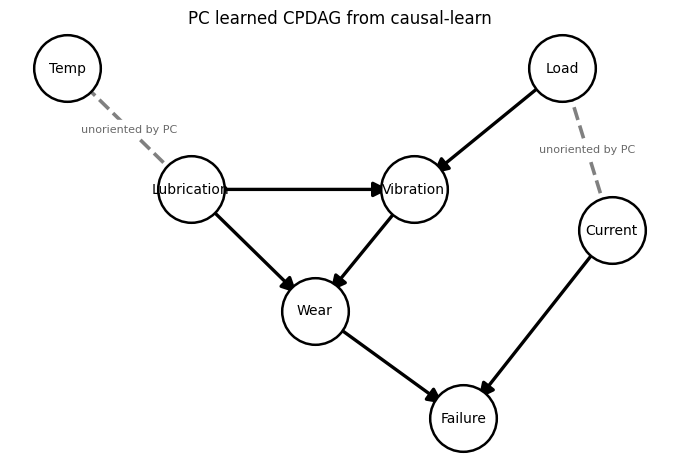

Directed PC edges: [('Current', 'Failure'), ('Load', 'Vibration'), ('Lubrication', 'Vibration'), ('Lubrication', 'Wear'), ('Vibration', 'Wear'), ('Wear', 'Failure')]
Unoriented PC edges: [('Current', 'Load'), ('Lubrication', 'Temp')]


In [23]:

draw_graph(
    pc_result["directed_edges"],
    pc_result["undirected_edges"],
    title="PC learned CPDAG from causal-learn",
    undirected_label="unoriented by PC",
)

print("Directed PC edges:", pc_result["directed_edges"])
print("Unoriented PC edges:", pc_result["undirected_edges"])



For this synthetic dataset, `causal-learn` recovers the exact skeleton. It leaves `Temp -- Lubrication` and `Load -- Current` unoriented because the observational conditional independences do not distinguish the two possible directions inside the Markov equivalence class. This does **not** mean the generating SCM was undirected; it means PC could not infer those arrow directions from observational data alone.

**Short exercise:** Change `alpha` in `run_pc_discovery(X, alpha=1e-3)` to `0.05`. Which edges change? Why can the independence-test threshold affect graph recovery? <br>
if we change alpha value we are changing the treshold for keeping vs. not keeping an arch <br>
- alpha small (e.g: 0.001) we are more hard, we want small p_values to have relationship (we want to be sure);
- alpha big (e.g: 0.1 or 0.05) we are being more flexible, permit p_values bigger (less certainty).


In [30]:

pc_result = run_pc_discovery(X, alpha=0.05)
true_skeleton = sorted(tuple(sorted(e)) for e in scm.graph.edges())

print("True skeleton equals learned skeleton:", set(true_skeleton) == set(pc_result["skeleton"]))
display(pc_result["edge_table"])


True skeleton equals learned skeleton: True


,edge,PC_status,endpoint_1,endpoint_2
0,Temp -- Lubrication,unoriented by PC,TAIL,TAIL
1,Load -- Current,unoriented by PC,TAIL,TAIL
2,Load -> Vibration,directed by PC,TAIL,ARROW
3,Lubrication -> Vibration,directed by PC,TAIL,ARROW
4,Lubrication -> Wear,directed by PC,TAIL,ARROW
5,Current -> Failure,directed by PC,TAIL,ARROW
6,Vibration -> Wear,directed by PC,TAIL,ARROW
7,Wear -> Failure,directed by PC,TAIL,ARROW


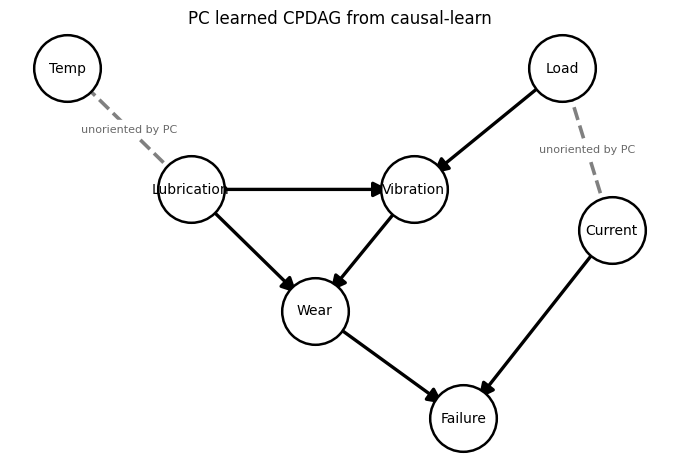

Directed PC edges: [('Current', 'Failure'), ('Load', 'Vibration'), ('Lubrication', 'Vibration'), ('Lubrication', 'Wear'), ('Vibration', 'Wear'), ('Wear', 'Failure')]
Unoriented PC edges: [('Current', 'Load'), ('Lubrication', 'Temp')]


In [31]:

draw_graph(
    pc_result["directed_edges"],
    pc_result["undirected_edges"],
    title="PC learned CPDAG from causal-learn",
    undirected_label="unoriented by PC",
)

print("Directed PC edges:", pc_result["directed_edges"])
print("Unoriented PC edges:", pc_result["undirected_edges"])



## 3. Level 2: intervention and the backdoor criterion

Now move from association to intervention.

We will estimate the causal effect of **Wear** on **Failure**.

The observational regression

$$
E[\text{Failure} \mid \text{Wear}]
$$

is **not** automatically causal, because of the backdoor path

$$
\text{Wear} \leftarrow \text{Vibration} \leftarrow \text{Load} \to \text{Current} \to \text{Failure}.
$$

A valid adjustment set must block every backdoor path without conditioning on descendants of the treatment.

The important implementation detail is that we pass DoWhy the existing `networkx.DiGraph` directly. This avoids the Colab Graphviz parser dependency that can be triggered when DoWhy is asked to parse a DOT string.


meaning: if we want to be sure that Wear->Failure, we need to eliminate other possible influence of wear and failure. <br>
right now it could be that W and F increase together because there is Load that increase both of them, without a real causality between them. <br>
To prove real causality we have to make all other possible influences not influencing. So we Condition to make them indipendent.

In [32]:

dowhy_model = CausalModel(
    data=X,
    treatment="Wear",
    outcome="Failure",
    graph=scm.graph.copy(),
)

identified_estimand = dowhy_model.identify_effect(
    method_name="minimal-adjustment",
    proceed_when_unidentifiable=True,
)

selected_adjustment_set = identified_estimand.get_backdoor_variables()

backdoor_rows = []
for set_id, variables in identified_estimand.backdoor_variables.items():
    if set_id == "backdoor":
        continue
    backdoor_rows.append({
        "DoWhy_set_id": set_id,
        "adjustment_variables": variables,
        "selected_for_estimation": variables == selected_adjustment_set,
    })

print("DoWhy-selected backdoor adjustment set:", selected_adjustment_set)
print("DoWhy backdoor estimand:")
print(identified_estimand.estimands.get("backdoor"))

display(pd.DataFrame(backdoor_rows))
display(pd.DataFrame([
    {"DoWhy_general_adjustment_id": key, "adjustment_variables": value}
    for key, value in identified_estimand.general_adjustment_variables.items()
]))


DoWhy-selected backdoor adjustment set: ['Load']
DoWhy backdoor estimand:
{'estimand': Derivative(Expectation(Failure|Load), [Wear]), 'assumptions': {'Unconfoundedness': 'If U→{Wear} and U→Failure then P(Failure|Wear,Load,U) = P(Failure|Wear,Load)'}}


,DoWhy_set_id,adjustment_variables,selected_for_estimation
0,backdoor1,[Load],True
1,backdoor2,[Current],False


,DoWhy_general_adjustment_id,adjustment_variables
0,general1,"[Lubrication, Vibration]"
1,general_adjustment,"[Lubrication, Vibration]"


meaning of table:
- select Load as the conditioned var for eliminationg the backdoor bw/ wear and failure
- it existamete thet there are NO hidden vars U OR that they are inside Load (so not important as we condition it)
- there are 2 vars possible to condition for eliminationg the backdoor but we use Load (could use Current)
- could use (Lub and Vibration) to block the backdoor too. Tho using the minimun set is better usually.


DoWhy identifies the adjustment variables from the graph **before** estimation. The notebook does not hardcode `Load`; it reads the selected set from `identified_estimand.get_backdoor_variables()` and then builds the adjusted regression formula from that set.

For this SCM, DoWhy reports the valid adjustment sets it finds and marks one selected set for estimation. Multiple valid adjustment sets can exist because different sets of non-descendants may block the same backdoor paths, so `Load`, `Current`, and `[Vibration, Lubrication]` are alternative ways to identify the same causal effect rather than contradictory answers. The adjusted regression below uses that selected set programmatically, so the formula follows DoWhy rather than a hardcoded classroom choice.


In [35]:

adjustment_rhs = " + ".join(selected_adjustment_set)
naive_formula = "Failure ~ Wear"
adjusted_formula = "Failure ~ Wear" + (f" + {adjustment_rhs}" if adjustment_rhs else "")

naive_model = smf.ols(naive_formula, data=X).fit()
adjusted_model = smf.ols(adjusted_formula, data=X).fit()

dowhy_estimate_1_unit = dowhy_model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression",
    control_value=float(X["Wear"].mean()),
    treatment_value=float(X["Wear"].mean() + 1.0),
)

print("Naive formula:", naive_formula)
print("Adjusted formula built from DoWhy-selected set:", adjusted_formula)
print("DoWhy linear-regression estimate for +1 Wear unit:", dowhy_estimate_1_unit.value)

display(pd.DataFrame({
    "naive observational regression": naive_model.params,
    "DoWhy-selected adjusted regression": adjusted_model.params,
}))


Naive formula: Failure ~ Wear
Adjusted formula built from DoWhy-selected set: Failure ~ Wear + Load
DoWhy linear-regression estimate for +1 Wear unit: 0.9725683614598921


,naive observational regression,DoWhy-selected adjusted regression
Intercept,-15.420,-25.893
Load,NaN,0.245
Wear,1.109,0.975


In [36]:

def build_dowhy_gcm_model(graph, data):
    model = gcm.InvertibleStructuralCausalModel(graph.copy())
    for node in nx.topological_sort(graph):
        if graph.in_degree(node) == 0:
            model.set_causal_mechanism(node, gcm.EmpiricalDistribution())
        else:
            model.set_causal_mechanism(node, gcm.AdditiveNoiseModel(gcm_ml.create_linear_regressor()))

    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        gcm.fit(model, data)
    return model


gcm_model = build_dowhy_gcm_model(scm.graph, X)


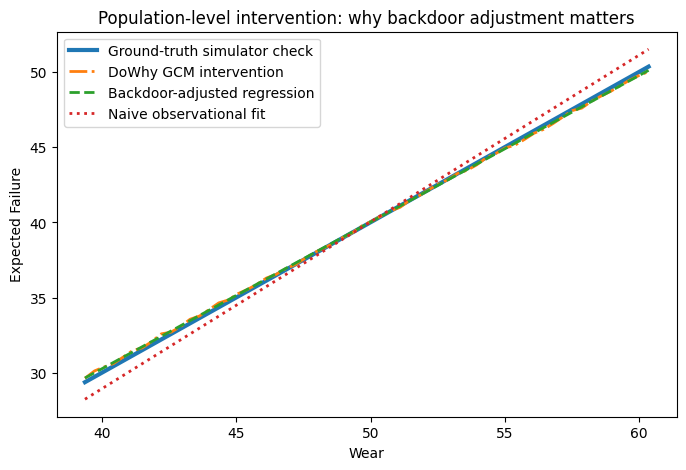

,quantity,value
0,True causal slope from the data-generating SCM,1.000
1,Naive slope from Failure ~ Wear,1.109
2,Adjusted slope using DoWhy-selected set,0.975
3,DoWhy estimate for +1 Wear unit,0.973


In [37]:

wear_grid = np.linspace(X["Wear"].quantile(0.05), X["Wear"].quantile(0.95), 60)

naive_curve = naive_model.params["Intercept"] + naive_model.params["Wear"] * wear_grid

adjusted_curve = adjusted_model.params["Intercept"] + adjusted_model.params["Wear"] * wear_grid
for variable in selected_adjustment_set:
    adjusted_curve += adjusted_model.params[variable] * X[variable].mean()

# DoWhy GCM population intervention.
dowhy_gcm_curve = np.asarray([
    gcm.interventional_samples(
        gcm_model,
        interventions={"Wear": lambda old, w=w: float(w)},
        num_samples_to_draw=6000,
    )["Failure"].mean()
    for w in wear_grid
])

# Ground-truth simulator check from the known data-generating SCM.
U_pop = scm.sample_exogenous(n=20000, seed=SEED + 1)
true_curve = np.asarray([
    scm.evaluate(U_pop, interventions={"Wear": float(w)})["Failure"].mean()
    for w in wear_grid
])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(wear_grid, true_curve, label="Ground-truth simulator check", linewidth=3)
ax.plot(wear_grid, dowhy_gcm_curve, label="DoWhy GCM intervention", linestyle="-.", linewidth=2)
ax.plot(wear_grid, adjusted_curve, label="Backdoor-adjusted regression", linestyle="--", linewidth=2)
ax.plot(wear_grid, naive_curve, label="Naive observational fit", linestyle=":", linewidth=2)
ax.set_xlabel("Wear")
ax.set_ylabel("Expected Failure")
ax.set_title("Population-level intervention: why backdoor adjustment matters")
ax.legend()
plt.show()

pd.DataFrame({
    "quantity": [
        "True causal slope from the data-generating SCM",
        "Naive slope from Failure ~ Wear",
        "Adjusted slope using DoWhy-selected set",
        "DoWhy estimate for +1 Wear unit",
    ],
    "value": [
        1.0,
        naive_model.params["Wear"],
        adjusted_model.params["Wear"],
        dowhy_estimate_1_unit.value,
    ],
})



The lesson is the core message of level 2:

- `Failure ~ Wear` answers an observational question;
- DoWhy identifies a valid adjustment set from the graph before estimation;
- the adjusted estimate and the DoWhy GCM intervention line up with the known data-generating simulator, while the naive estimate is biased.

**Short exercise:** Estimate the causal effect of `Current` on `Failure`. Create a new `CausalModel`, call `identify_effect`, inspect `get_backdoor_variables()`, and compare the naive and adjusted formulas.


In [38]:

dowhy_model = CausalModel(
    data=X,
    treatment="Current",
    outcome="Failure",
    graph=scm.graph.copy(),
)

identified_estimand = dowhy_model.identify_effect(
    method_name="minimal-adjustment",
    proceed_when_unidentifiable=True,
)

selected_adjustment_set = identified_estimand.get_backdoor_variables()

backdoor_rows = []
for set_id, variables in identified_estimand.backdoor_variables.items():
    if set_id == "backdoor":
        continue
    backdoor_rows.append({
        "DoWhy_set_id": set_id,
        "adjustment_variables": variables,
        "selected_for_estimation": variables == selected_adjustment_set,
    })

print("DoWhy-selected backdoor adjustment set:", selected_adjustment_set)
print("DoWhy backdoor estimand:")
print(identified_estimand.estimands.get("backdoor"))

display(pd.DataFrame(backdoor_rows))
display(pd.DataFrame([
    {"DoWhy_general_adjustment_id": key, "adjustment_variables": value}
    for key, value in identified_estimand.general_adjustment_variables.items()
]))


DoWhy-selected backdoor adjustment set: ['Load']
DoWhy backdoor estimand:
{'estimand': Derivative(Expectation(Failure|Load), [Current]), 'assumptions': {'Unconfoundedness': 'If U→{Current} and U→Failure then P(Failure|Current,Load,U) = P(Failure|Current,Load)'}}


,DoWhy_set_id,adjustment_variables,selected_for_estimation
0,backdoor1,[Load],True
1,backdoor2,[Wear],False


,DoWhy_general_adjustment_id,adjustment_variables
0,general1,[Load]
1,general_adjustment,[Load]


make sense, to break the backdoor we can influence the fork or the chain

In [39]:

adjustment_rhs = " + ".join(selected_adjustment_set)
naive_formula = "Failure ~ Current"
adjusted_formula = "Failure ~ Current" + (f" + {adjustment_rhs}" if adjustment_rhs else "")

naive_model = smf.ols(naive_formula, data=X).fit()
adjusted_model = smf.ols(adjusted_formula, data=X).fit()

dowhy_estimate_1_unit = dowhy_model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression",
    control_value=float(X["Current"].mean()),
    treatment_value=float(X["Current"].mean() + 1.0),
)

print("Naive formula:", naive_formula)
print("Adjusted formula built from DoWhy-selected set:", adjusted_formula)
print("DoWhy linear-regression estimate for +1 Wear unit:", dowhy_estimate_1_unit.value)

display(pd.DataFrame({
    "naive observational regression": naive_model.params,
    "DoWhy-selected adjusted regression": adjusted_model.params,
}))


Naive formula: Failure ~ Current
Adjusted formula built from DoWhy-selected set: Failure ~ Current + Load
DoWhy linear-regression estimate for +1 Wear unit: 0.7937964128016972


,naive observational regression,DoWhy-selected adjusted regression
Current,1.338,0.828
Intercept,-0.221,-0.371
Load,NaN,0.220


Meaning: if we leave th backdoor the influence of Current over failure is 1.3<br>
instead if we condition on Load, breakig the backdoor, we get 0.8 <br>
the relative differnece is 60%. So with the backdoor we were influencing 60% more, messing up the values a lot.

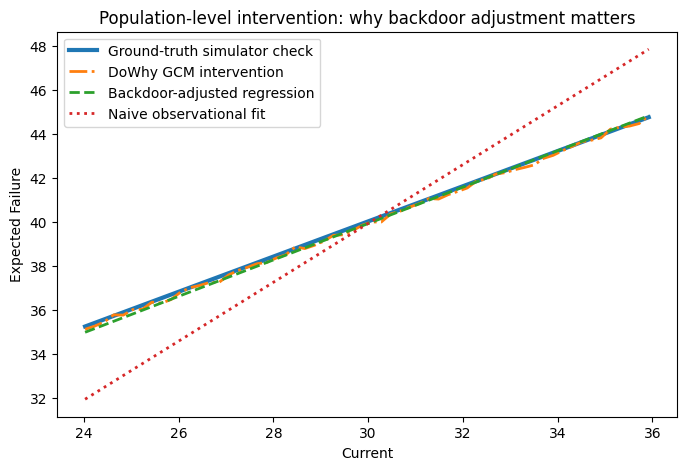

,quantity,value
0,True causal slope from the data-generating SCM,1.000
1,Naive slope from Failure ~ Current,1.338
2,Adjusted slope using DoWhy-selected set,0.828
3,DoWhy estimate for +1 Current unit,0.794


In [42]:

wear_grid = np.linspace(X["Current"].quantile(0.05), X["Current"].quantile(0.95), 60)

naive_curve = naive_model.params["Intercept"] + naive_model.params["Current"] * wear_grid

adjusted_curve = adjusted_model.params["Intercept"] + adjusted_model.params["Current"] * wear_grid
for variable in selected_adjustment_set:
    adjusted_curve += adjusted_model.params[variable] * X[variable].mean()

# DoWhy GCM population intervention.
dowhy_gcm_curve = np.asarray([
    gcm.interventional_samples(
        gcm_model,
        interventions={"Current": lambda old, w=w: float(w)},
        num_samples_to_draw=6000,
    )["Failure"].mean()
    for w in wear_grid
])

# Ground-truth simulator check from the known data-generating SCM.
U_pop = scm.sample_exogenous(n=20000, seed=SEED + 1)
true_curve = np.asarray([
    scm.evaluate(U_pop, interventions={"Current": float(w)})["Failure"].mean()
    for w in wear_grid
])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(wear_grid, true_curve, label="Ground-truth simulator check", linewidth=3)
ax.plot(wear_grid, dowhy_gcm_curve, label="DoWhy GCM intervention", linestyle="-.", linewidth=2)
ax.plot(wear_grid, adjusted_curve, label="Backdoor-adjusted regression", linestyle="--", linewidth=2)
ax.plot(wear_grid, naive_curve, label="Naive observational fit", linestyle=":", linewidth=2)
ax.set_xlabel("Current")
ax.set_ylabel("Expected Failure")
ax.set_title("Population-level intervention: why backdoor adjustment matters")
ax.legend()
plt.show()

pd.DataFrame({
    "quantity": [
        "True causal slope from the data-generating SCM",
        "Naive slope from Failure ~ Current",
        "Adjusted slope using DoWhy-selected set",
        "DoWhy estimate for +1 Current unit",
    ],
    "value": [
        1.0,
        naive_model.params["Current"],
        adjusted_model.params["Current"],
        dowhy_estimate_1_unit.value,
    ],
})



## 4. Level 3: linear structural equations, sigma variations, and counterfactuals

At level 3 we no longer average over the population. We reason about **the same individual machine**.

A useful way to rewrite a linear SCM is:

$$
X_j = \mu_j + \sum_{k \in Pa(j)} \beta_{jk}(X_k - \mu_k) + U_j.
$$

The term $U_j$ is the **exogenous shock** for that node. In Pearl's framework, these exogenous variables matter because they help define the *individual*. (diff from average is the individual)

Two machines may have similar observed values but different exogenous shocks; counterfactual reasoning keeps those individual shocks fixed.


In [43]:

parents = {
    "Lubrication": ["Temp"],
    "Vibration": ["Load", "Lubrication"],
    "Wear": ["Vibration", "Lubrication"],
    "Current": ["Load"],
    "Failure": ["Wear", "Current"],
}

means = X.mean()
stds = X.std(ddof=0)
Z = (X - means) / stds

rows = []
for child, pa in parents.items():
    formula = child + " ~ " + " + ".join(pa)
    model_raw = smf.ols(formula, data=X).fit()
    model_z = smf.ols(formula, data=Z).fit()

    rows.append({
        "equation": formula,
        "intercept(raw units)": model_raw.params["Intercept"],
        "residual_sd(raw units)": np.sqrt(model_raw.scale),
        "sigma_coefficients": ", ".join([f"{p}: {model_z.params[p]:.3f}" for p in pa]),
    })

linear_summary = pd.DataFrame(rows)
linear_summary


,equation,intercept(raw units),residual_sd(raw units),sigma_coefficients
0,Lubrication ~ Temp,108.934,4.998,Temp: -0.640
1,Vibration ~ Load + Lubrication,8.534,1.178,"Load: 0.583, Lubrication: -0.450"
2,Wear ~ Vibration + Lubrication,73.553,2.959,"Vibration: 0.585, Lubrication: -0.455"
3,Current ~ Load,8.808,1.991,Load: 0.836
4,Failure ~ Wear + Current,-32.858,3.984,"Wear: 0.728, Current: 0.336"


In [44]:

z_equations = []
for child, pa in parents.items():
    model_z = smf.ols(child + " ~ " + " + ".join(pa), data=Z).fit()
    rhs = " + ".join([f"({model_z.params[p]:.3f}) * z_{p}" for p in pa])
    z_equations.append(f"z_{child} approx {rhs} + u_tilde_{child}")

print("Centred / sigma-scale structural approximations:")
print()
for eq in z_equations:
    print(eq)


Centred / sigma-scale structural approximations:

z_Lubrication approx (-0.640) * z_Temp + u_tilde_Lubrication
z_Vibration approx (0.583) * z_Load + (-0.450) * z_Lubrication + u_tilde_Vibration
z_Wear approx (0.585) * z_Vibration + (-0.455) * z_Lubrication + u_tilde_Wear
z_Current approx (0.836) * z_Load + u_tilde_Current
z_Failure approx (0.728) * z_Wear + (0.336) * z_Current + u_tilde_Failure


A coefficient on the sigma scale says what happens to the child variable, in standard-deviation units, when the parent moves by one standard deviation and everything else is held fixed.

In this notebook we use the same population-style standard deviation convention (`ddof=0`) both for sigma-scale standardisation and for the later `+1 sd` counterfactual shifts.

Next we pick one machine with unusually high failure risk. The manual abduction table is shown only because the data-generating SCM is known in this synthetic lab; the library counterfactual samples below come from DoWhy GCM.


In [ ]:

idx = X["Failure"].idxmax() #machine with highest failure value, meaning it's an individual
obs_machine = X.loc[idx]
U_hat = scm.abduce(obs_machine).T.rename(columns={0: "inferred_exogenous_shock_from_known_SCM"})

print(f"Selected machine index: {idx}")
display(obs_machine.to_frame("observed_value"))
display(U_hat)


Selected machine index: 2240


,observed_value
Temp,29.169
Load,79.007
Lubrication,67.170
Current,33.421
Vibration,9.657
Wear,68.079
Failure,71.289


,inferred_exogenous_shock_from_known_SCM
U_Temp,1.169
U_Load,9.007
U_Lubrication,-11.660
U_Vibration,1.216
U_Wear,4.261
U_Current,0.719
U_Failure,10.473


### 4.1 Counterfactuals by abduction, action, prediction

We now ask two individual-level *what if* questions for the **same machine**:

1. what if its **Lubrication** had been improved by one population standard deviation?
2. what if its **Load** had been reduced by one population standard deviation?

The crucial step is that the counterfactual keeps the machine-specific exogenous information fixed. `dowhy.gcm.counterfactual_samples` performs this abduction-action-prediction workflow for the fitted GCM.

Because the DoWhy GCM is estimated from finite data while the manual calculation uses the known simulator, the two counterfactual answers should be close but not exactly identical.


In [ ]:
#obs_machine is the most failure heavy one
lub_plus_1sd = obs_machine["Lubrication"] + X["Lubrication"].std(ddof=0)
load_minus_1sd = obs_machine["Load"] - X["Load"].std(ddof=0)
obs_df = obs_machine.to_frame().T

dowhy_cf_lub = gcm.counterfactual_samples(
    gcm_model,
    interventions={"Lubrication": lambda old: float(lub_plus_1sd)},
    observed_data=obs_df,
).iloc[0]

dowhy_cf_load = gcm.counterfactual_samples(
    gcm_model,
    interventions={"Load": lambda old: float(load_minus_1sd)},
    observed_data=obs_df,
).iloc[0]

# Ground-truth simulator check from the known SCM equations.
manual_cf_lub = scm.counterfactual(obs_machine, interventions={"Lubrication": float(lub_plus_1sd)})
manual_cf_load = scm.counterfactual(obs_machine, interventions={"Load": float(load_minus_1sd)})

cf_table = pd.DataFrame({
    "observed": obs_machine,
    "DoWhy GCM cf: Lubrication +1sd": dowhy_cf_lub,
    "DoWhy GCM cf: Load -1sd": dowhy_cf_load,
    "ground-truth simulator cf: Lubrication +1sd": manual_cf_lub,
    "ground-truth simulator cf: Load -1sd": manual_cf_load,
})

cf_table.loc[["Lubrication", "Load", "Vibration", "Wear", "Current", "Failure"]]


,observed,DoWhy GCM cf: Lubrication +1sd,DoWhy GCM cf: Load -1sd,ground-truth simulator cf: Lubrication +1sd,ground-truth simulator cf: Load -1sd
Lubrication,67.170,73.671,67.170,73.671,67.170
Load,79.007,79.007,68.962,79.007,68.962
Vibration,9.657,8.864,8.630,8.876,8.652
Wear,68.079,63.386,65.849,63.437,65.869
Current,33.421,33.421,30.385,33.421,30.408
Failure,71.289,66.722,66.667,66.647,66.668


it's confronting the data-learned model vs the ground-truth (the teoretical one) to see if the model is working fine even in these "what if" scenarios (mod 1 thing, leave others the same==counterfactual).

In [48]:

# Compare one individual-level counterfactual with a population-level intervention on the same variable.
pop_baseline = gcm.interventional_samples(
    gcm_model,
    interventions={},
    num_samples_to_draw=20000,
)["Failure"].mean()

pop_do_lub = gcm.interventional_samples(
    gcm_model,
    interventions={"Lubrication": lambda old: float(lub_plus_1sd)},
    num_samples_to_draw=20000,
)["Failure"].mean()

comparison_level2_vs_level3 = pd.DataFrame({
    "quantity": [
        "DoWhy GCM population mean Failure (baseline)",
        "DoWhy GCM population mean Failure under do(Lubrication = selected machine + 1sd)",
        "Observed selected machine Failure",
        "DoWhy GCM selected machine counterfactual Failure under Lubrication +1sd",
    ],
    "value": [
        pop_baseline,
        pop_do_lub,
        obs_machine["Failure"],
        dowhy_cf_lub["Failure"],
    ],
})
comparison_level2_vs_level3


,quantity,value
0,DoWhy GCM population mean Failure (baseline),39.952
1,DoWhy GCM population mean Failure under do(Lub...,44.383
2,Observed selected machine Failure,71.289
3,DoWhy GCM selected machine counterfactual Fail...,66.722



The individual counterfactual is not the same object as a population intervention:

- the population intervention samples many machines and averages over them;
- the individual counterfactual keeps one selected machine's inferred exogenous information fixed and changes only the intervention target.

**Short exercise:** Pick the machine closest to median `Failure` instead of the maximum-failure machine. Do the same interventions have the same size effect on `Failure`? Why or why not?


In [50]:
median_value = X["Failure"].median()
idx = (X["Failure"] - median_value).abs().idxmin()
obs_machine = X.loc[idx]
U_hat = scm.abduce(obs_machine).T.rename(columns={0: "inferred_exogenous_shock_from_known_SCM"})

print(f"Selected machine index: {idx}")
display(obs_machine.to_frame("observed_value"))
display(U_hat)

Selected machine index: 1058


,observed_value
Temp,28.008
Load,71.464
Lubrication,84.293
Current,32.339
Vibration,3.824
Wear,49.455
Failure,39.954


,inferred_exogenous_shock_from_known_SCM
U_Temp,0.008
U_Load,1.464
U_Lubrication,4.301
U_Vibration,-1.807
U_Wear,6.172
U_Current,1.900
U_Failure,-1.372


In [51]:
#obs_machine is the most failure heavy one
lub_plus_1sd = obs_machine["Lubrication"] + X["Lubrication"].std(ddof=0)
load_minus_1sd = obs_machine["Load"] - X["Load"].std(ddof=0)
obs_df = obs_machine.to_frame().T

dowhy_cf_lub = gcm.counterfactual_samples(
    gcm_model,
    interventions={"Lubrication": lambda old: float(lub_plus_1sd)},
    observed_data=obs_df,
).iloc[0]

dowhy_cf_load = gcm.counterfactual_samples(
    gcm_model,
    interventions={"Load": lambda old: float(load_minus_1sd)},
    observed_data=obs_df,
).iloc[0]

# Ground-truth simulator check from the known SCM equations.
manual_cf_lub = scm.counterfactual(obs_machine, interventions={"Lubrication": float(lub_plus_1sd)})
manual_cf_load = scm.counterfactual(obs_machine, interventions={"Load": float(load_minus_1sd)})

cf_table = pd.DataFrame({
    "observed": obs_machine,
    "DoWhy GCM cf: Lubrication +1sd": dowhy_cf_lub,
    "DoWhy GCM cf: Load -1sd": dowhy_cf_load,
    "ground-truth simulator cf: Lubrication +1sd": manual_cf_lub,
    "ground-truth simulator cf: Load -1sd": manual_cf_load,
})

cf_table.loc[["Lubrication", "Load", "Vibration", "Wear", "Current", "Failure"]]


,observed,DoWhy GCM cf: Lubrication +1sd,DoWhy GCM cf: Load -1sd,ground-truth simulator cf: Lubrication +1sd,ground-truth simulator cf: Load -1sd
Lubrication,84.293,90.794,84.293,90.794,84.293
Load,71.464,71.464,61.419,71.464,61.419
Vibration,3.824,3.032,2.798,3.044,2.820
Wear,49.455,44.761,47.224,44.813,47.245
Current,32.339,32.339,29.302,32.339,29.325
Failure,39.954,35.387,35.331,35.312,35.333


In [52]:
# Compare one individual-level counterfactual with a population-level intervention on the same variable.
pop_baseline = gcm.interventional_samples(
    gcm_model,
    interventions={},
    num_samples_to_draw=20000,
)["Failure"].mean()

pop_do_lub = gcm.interventional_samples(
    gcm_model,
    interventions={"Lubrication": lambda old: float(lub_plus_1sd)},
    num_samples_to_draw=20000,
)["Failure"].mean()

comparison_level2_vs_level3 = pd.DataFrame({
    "quantity": [
        "DoWhy GCM population mean Failure (baseline)",
        "DoWhy GCM population mean Failure under do(Lubrication = selected machine + 1sd)",
        "Observed selected machine Failure",
        "DoWhy GCM selected machine counterfactual Failure under Lubrication +1sd",
    ],
    "value": [
        pop_baseline,
        pop_do_lub,
        obs_machine["Failure"],
        dowhy_cf_lub["Failure"],
    ],
})
comparison_level2_vs_level3

,quantity,value
0,DoWhy GCM population mean Failure (baseline),39.974
1,DoWhy GCM population mean Failure under do(Lub...,32.278
2,Observed selected machine Failure,39.954
3,DoWhy GCM selected machine counterfactual Fail...,35.387



## 5. Optional exercises

1. Change the sample size from `3000` to `300` and observe how the PC result changes.
2. Compare Fisher-Z and permutation residual p-values for a nonlinear modification of the SCM.
3. Use DoWhy to identify adjustment variables for the causal effect of `Current` on `Failure`.
4. Add one hidden common cause between `Load` and `Lubrication` and discuss what breaks.
5. Modify the SCM so that `Failure` is binary and compare linear-regression estimation with logistic modelling.

**Short exercise:** Choose one of the five exercises above and add a one-paragraph answer explaining whether it changes association, intervention, counterfactual reasoning, or all three.


### 1 : 300 samples

In [54]:

X, U = scm.sample(n=300, seed=SEED)

print("Observed data shape:", X.shape)
print("Exogenous shocks shape:", U.shape)
display(X.head())
display(X.describe().T[["mean", "std", "min", "max"]])


Observed data shape: (300, 7)
Exogenous shocks shape: (300, 7)


,Temp,Load,Lubrication,Current,Vibration,Wear,Failure
0,25.736,70.463,79.706,32.776,4.619,48.406,36.356
1,29.612,61.407,75.662,27.304,5.182,55.582,43.288
2,24.085,72.283,85.102,28.760,6.864,45.897,36.079
3,30.287,54.289,81.080,25.560,5.331,46.226,31.343
4,22.642,66.887,88.265,26.185,3.467,45.463,31.721


,mean,std,min,max
Temp,28.263,3.967,16.199,39.160
Load,70.055,9.951,40.866,111.836
Lubrication,79.745,6.375,61.061,99.123
Current,29.919,3.818,19.210,43.722
Vibration,5.944,1.783,0.902,11.476
Wear,50.108,6.744,27.575,72.820
Failure,39.964,9.357,5.431,69.530


In [55]:
pc_result = run_pc_discovery(X, alpha=1e-3)
true_skeleton = sorted(tuple(sorted(e)) for e in scm.graph.edges())

print("True skeleton equals learned skeleton:", set(true_skeleton) == set(pc_result["skeleton"]))
display(pc_result["edge_table"])

True skeleton equals learned skeleton: False


,edge,PC_status,endpoint_1,endpoint_2
0,Temp -- Lubrication,unoriented by PC,TAIL,TAIL
1,Load -- Current,unoriented by PC,TAIL,TAIL
2,Load -> Vibration,directed by PC,TAIL,ARROW
3,Lubrication -- Wear,unoriented by PC,TAIL,TAIL
4,Current -> Failure,directed by PC,TAIL,ARROW
5,Wear -> Vibration,directed by PC,TAIL,ARROW
6,Wear -> Failure,directed by PC,TAIL,ARROW


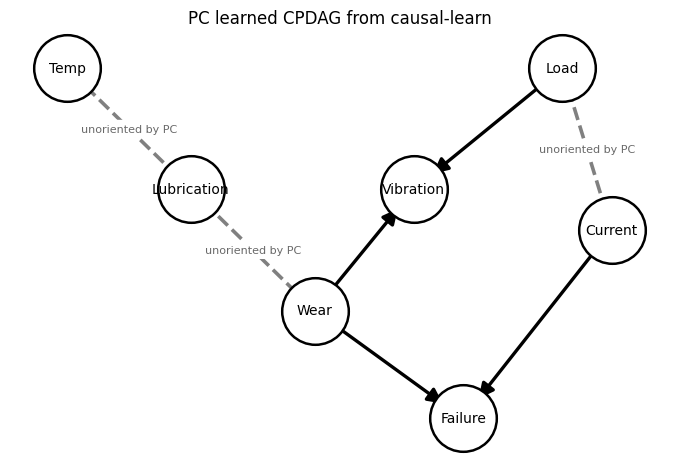

Directed PC edges: [('Current', 'Failure'), ('Load', 'Vibration'), ('Wear', 'Failure'), ('Wear', 'Vibration')]
Unoriented PC edges: [('Current', 'Load'), ('Lubrication', 'Temp'), ('Lubrication', 'Wear')]


In [56]:

draw_graph(
    pc_result["directed_edges"],
    pc_result["undirected_edges"],
    title="PC learned CPDAG from causal-learn",
    undirected_label="unoriented by PC",
)

print("Directed PC edges:", pc_result["directed_edges"])
print("Unoriented PC edges:", pc_result["undirected_edges"])

the samples are too little so the relationships are not really understood OR cannot be checked. Or the confidence is not enought 